# Data Importing and Preprocessing

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



## 2. Load the Dataset

In [45]:
df = pd.read_csv("data/raw_data/car_price.csv")
df.head()



,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [46]:
df.shape


(72435, 10)

## Task 1:

## 3. Exploratory Data Analysis (EDA)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  str    
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  str    
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  str    
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  str    
dtypes: float64(6), str(4)
memory usage: 5.5 MB


In [48]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


## 4. Determining which features are numerical and Which are categorical

In [49]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numerical Features:",numerical_cols)
print("\nCategorical Features:",categorical_cols)

Numerical Features: Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='str')

Categorical Features: Index(['model', 'transmission', 'fuelType', 'Make'], dtype='str')


/tmp/ipykernel_11073/3944902702.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## 5. Checking null values

In [50]:
df.isna().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

## 6.The distribution of car prices 

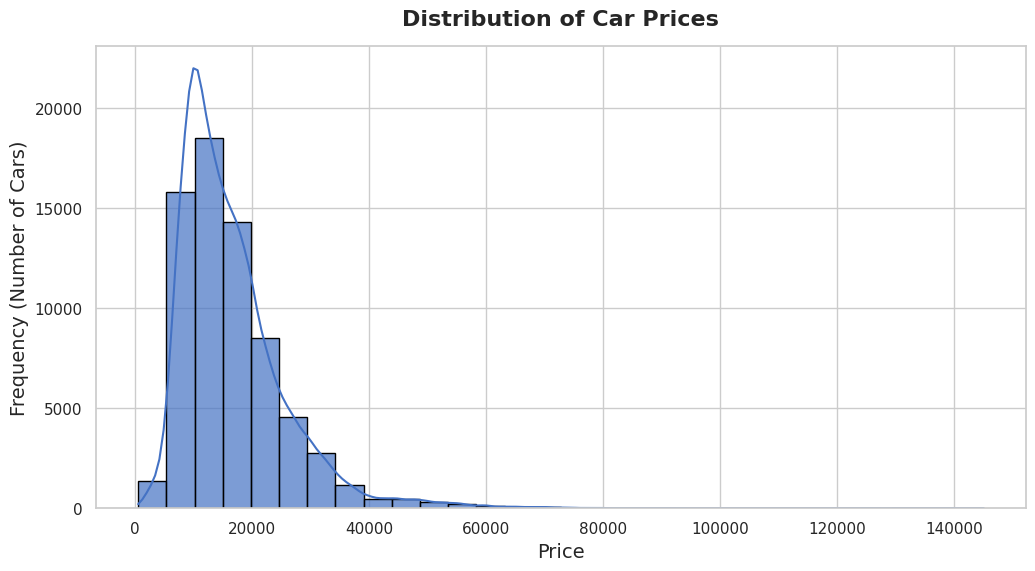

In [51]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.histplot(df['price'], bins=30, kde=True, color="#4472c4", edgecolor="black", alpha=0.7)

plt.title('Distribution of Car Prices', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Price', fontsize=14)
plt.ylabel('Frequency (Number of Cars)', fontsize=14)

plt.show()

## 7.Which features seem most related to price? 

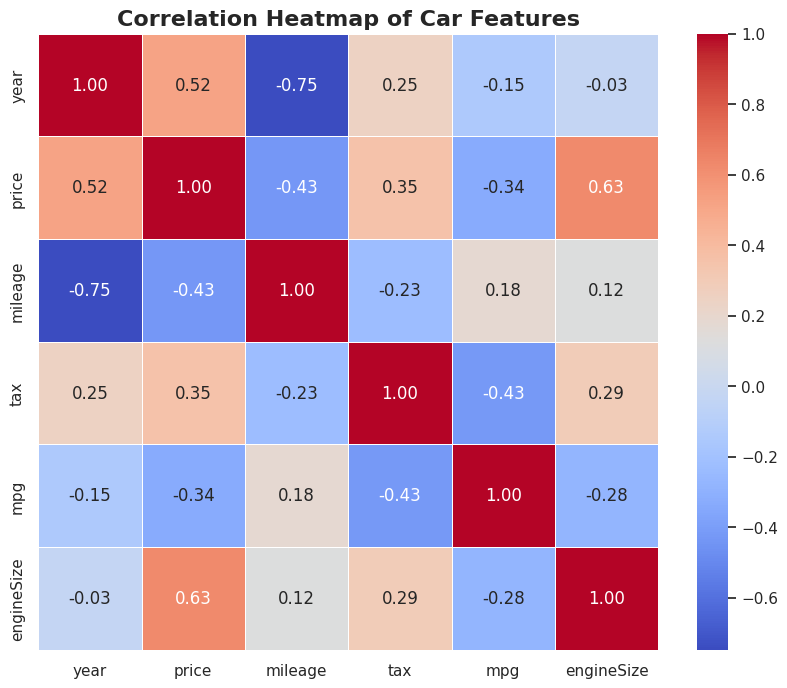

Features most related to price:
price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64


In [52]:

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)


plt.title('Correlation Heatmap of Car Features', fontsize=16, fontweight='bold')
plt.show()

print("Features most related to price:")
print(correlation_matrix['price'].sort_values(ascending=False))

## Task 2:
## 8.Split the data before preprocessing

This step ensures the test set remains unseen during cleaning, encoding, and scaling. By splitting first, we prevent data leakage and make the evaluation of the model more reliable.


In [53]:
# Drop rows without a target value, then split before any preprocessing.
df = df.dropna(subset=['price']).copy()
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

# Impute missing values using only training-set statistics.
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns
num_cols = X_train.select_dtypes(include=['number']).columns

train_cat_fill = {col: X_train[col].mode()[0] for col in cat_cols}
train_num_fill = {col: X_train[col].median() for col in num_cols}

for col in cat_cols:
    X_train[col] = X_train[col].fillna(train_cat_fill[col])
    X_test[col] = X_test[col].fillna(train_cat_fill[col])

for col in num_cols:
    X_train[col] = X_train[col].fillna(train_num_fill[col])
    X_test[col] = X_test[col].fillna(train_num_fill[col])

print('Missing values after imputation:')
print('train:', X_train.isna().sum().sum())
print('test:', X_test.isna().sum().sum())


Train shape: (55051, 9), Test shape: (13763, 9)
Missing values after imputation:
train: 0
test: 0


## 9.Encode categorical columns



In [54]:
categorical_cols = ['Make', 'model', 'transmission', 'fuelType']
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded_train = pd.DataFrame(
    enc.fit_transform(X_train[categorical_cols]),
    columns=enc.get_feature_names_out(categorical_cols),
    index=X_train.index
)
encoded_test = pd.DataFrame(
    enc.transform(X_test[categorical_cols]),
    columns=enc.get_feature_names_out(categorical_cols),
    index=X_test.index
)

X_train = X_train.drop(categorical_cols, axis=1)
X_test = X_test.drop(categorical_cols, axis=1)
X_train = pd.concat([X_train, encoded_train], axis=1)
X_test = pd.concat([X_test, encoded_test], axis=1)

X_train.head()


,year,mileage,tax,mpg,engineSize,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,...,model_ i8,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
19785,2019.0,3693.0,145.0,47.9,3.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
43740,2020.0,3000.0,150.0,32.8,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
61606,2019.0,14507.0,150.0,31.7,2.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
46219,2020.0,3000.0,145.0,47.9,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
63550,2019.0,1911.0,145.0,64.2,2.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


## 10.scaling numerical features

In [55]:
num_cols = ['year', 'engineSize','mpg','tax','mileage']
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


X_train.head()

,year,mileage,tax,mpg,engineSize,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,...,model_ i8,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
19785,0.942154,-0.919782,0.423593,-0.467505,2.498391,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
43740,1.430856,-0.952962,0.503067,-1.358811,0.669776,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
61606,0.942154,-0.402023,0.503067,-1.423741,0.669776,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
46219,1.430856,-0.952962,0.423593,-0.467505,-1.158839,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
63550,0.942154,-1.005101,0.423593,0.494634,0.669776,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


## 11.Detect and handle outliers 

In [56]:
# Remove extreme outliers from the training set only to avoid leaking test information.
outlier_cols = ['mileage', 'engineSize', 'mpg']

for col in outlier_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = X_train[col].between(lower_bound, upper_bound)
    removed = len(X_train) - mask.sum()
    X_train = X_train[mask]
    y_train = y_train[mask]

    print(f'Removed {removed} outliers from train set based on {col}')

print(f'New train shape after cleaning outliers: {X_train.shape}')


Removed 2413 outliers from train set based on mileage
Removed 241 outliers from train set based on engineSize
Removed 673 outliers from train set based on mpg
New train shape after cleaning outliers: (51724, 166)


## Task 3:
## A. Regression Target (Linear Regression)   

Linear Regression performance on test set:
  RMSE: 4039.06
  R^2: 0.8083

Top features by coefficient magnitude:
               feature   coefficient
156          model_ i8  35080.654761
149          model_ X7  32776.201020
44   model_ California  29363.656874
19     model_ 8 Series  26314.765945
105         model_ RS4  25252.705395
107         model_ RS6  23287.404910
101          model_ Q8  21400.359568
106         model_ RS5  20107.077877
126       model_ Supra  17880.614325
52       model_ Escort  15178.143735


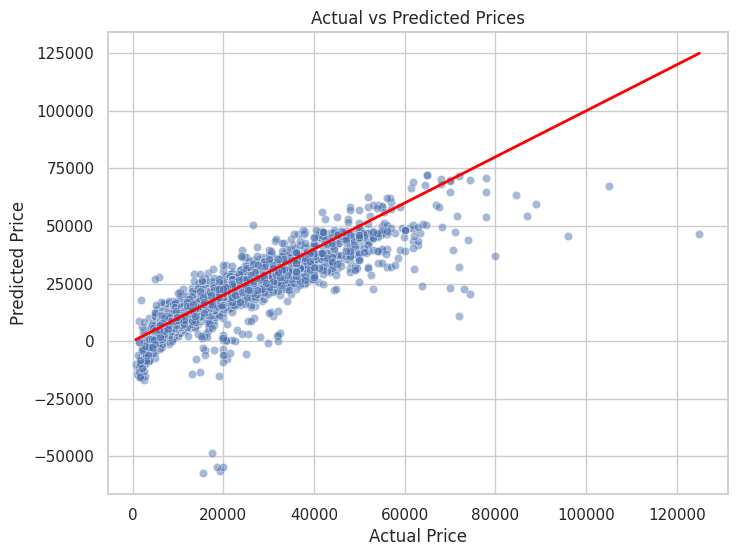

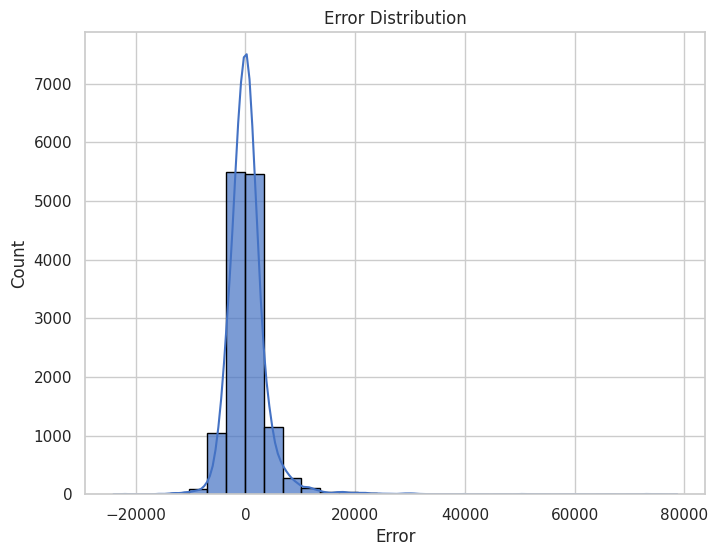

In [57]:
# Now train the model on the preprocessed training set.
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the unseen test set
y_pred = model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Linear Regression performance on test set:')
print(f'  RMSE: {rmse:.2f}')
print(f'  R^2: {r2:.4f}')

# Show the top coefficients by absolute value
coef_df = pd.DataFrame({ 'feature': X_train.columns, 'coefficient': model.coef_ })
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coefficient', ascending=False).drop(columns='abs_coefficient')
print('\nTop features by coefficient magnitude:')
print(coef_df.head(10))

# Plot predictions versus actual values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

# Plot error distribution
errors = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(errors, bins=30, kde=True, color='#4472c4', edgecolor='black', alpha=0.7)
plt.title('Error Distribution')
plt.xlabel('Error')
plt.ylabel('Count')
plt.show()
